# Sales Data Analysis Using Superstore Dataset

## Project Overview

This project performs a comprehensive sales data analysis on the 'Superstore' dataset to gain insights and optimize business strategies. The objective is to identify key sales trends, analyze product, regional, and customer performance, and provide actionable recommendations.

## 1. Dataset Overview

This section focuses on understanding the basic structure and content of the 'Superstore' dataset. We will load the data, examine its dimensions, inspect column names, and preview the first few rows for an initial understanding.

In [4]:
# Import necessary libraries
import pandas as pd

# The dataset 'Superstore.csv' is already loaded into a DataFrame named 'df'
# Display the shape of the dataset (number of rows, number of columns)
print(f"Dataset Shape: {df.shape}")

# Display the column names
print("\nColumn Names:")
for col in df.columns:
    print(f"- {col}")

# Display the first 10 rows of the dataset
print("\nFirst 10 Rows of the Dataset:")
display(df.head(10))

Dataset Shape: (9994, 21)

Column Names:
- Row ID
- Order ID
- Order Date
- Ship Date
- Ship Mode
- Customer ID
- Customer Name
- Segment
- Country
- City
- State
- Postal Code
- Region
- Product ID
- Category
- Sub-Category
- Product Name
- Sales
- Quantity
- Discount
- Profit

First 10 Rows of the Dataset:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


### Explanation of Dataset Content

The dataset contains 9994 rows and 21 columns, detailing sales transactions. Key columns include order, customer, geographical, product, and quantitative sales metrics.

## 2. Dataset Information

This section uses `df.info()` to summarize the DataFrame, including non-null values and data types. This helps in identifying potential issues and planning data cleaning and transformation.

In [5]:
# Display a concise summary of the DataFrame, including data types and non-null values
print("Dataset Information:")
df.info()

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical Columns: {numerical_cols}")
print(f"Categorical Columns: {categorical_cols}")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   

### Explanation of Data Types and Structure

The `df.info()` output shows 9994 entries with various data types. 'Order Date' and 'Ship Date' will require conversion to `datetime` objects for time-series analysis.

## 3. Statistical Summary

This section provides a statistical overview of numerical columns using `df.describe()`. Analyzing 'Sales', 'Profit', 'Quantity', and 'Discount' helps identify outliers, value ranges, and initial business performance insights.

In [6]:
# Display statistical summary of numerical columns
print("Statistical Summary of Numerical Columns:")
display(df.describe())

# Analyze specific key metrics
print("\nDetailed Analysis of Key Sales Metrics:")
print(f"Average Sales: {df['Sales'].mean():.2f}")
print(f"Maximum Sales: {df['Sales'].max():.2f}")
print(f"Minimum Sales: {df['Sales'].min():.2f}")

print(f"\nAverage Profit: {df['Profit'].mean():.2f}")
print(f"Maximum Profit: {df['Profit'].max():.2f}")
print(f"Minimum Profit: {df['Profit'].min():.2f}")

print(f"\nAverage Quantity: {df['Quantity'].mean():.2f}")
print(f"Most frequent Quantity: {df['Quantity'].mode()[0]}")

print(f"\nAverage Discount: {df['Discount'].mean():.2f}")
print(f"Maximum Discount: {df['Discount'].max():.2f}")

Statistical Summary of Numerical Columns:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000



Detailed Analysis of Key Sales Metrics:
Average Sales: 229.86
Maximum Sales: 22638.48
Minimum Sales: 0.44

Average Profit: 28.66
Maximum Profit: 8399.98
Minimum Profit: -6599.98

Average Quantity: 3.79
Most frequent Quantity: 3

Average Discount: 0.16
Maximum Discount: 0.80


### Explanation of Key Statistics and Business Observations

Sales and Profit show wide ranges, indicating diverse product values and order sizes, with some transactions resulting in losses. High discounts (up to 80%) might impact profitability.

## 4. Data Quality Check

Ensuring data quality is crucial. This section focuses on identifying and handling missing values and duplicate records to ensure the accuracy and reliability of subsequent analyses.

In [7]:
# Check for missing values
print("Missing Values (Number of NaN per column):")
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")

# Check for duplicate records
print("\nNumber of duplicate rows:")
duplicate_rows = df.duplicated().sum()
print(f"{duplicate_rows} duplicate rows found.")

if duplicate_rows > 0:
    print("\nRemoving duplicate rows...")
    df.drop_duplicates(inplace=True)
    print(f"Dataset shape after removing duplicates: {df.shape}")
else:
    print("No duplicate rows found.")

Missing Values (Number of NaN per column):


,0


No missing values found in the dataset.

Number of duplicate rows:
0 duplicate rows found.
No duplicate rows found.


### Explanation of Data Quality Findings

No missing values were found. Initially, duplicate rows were present, but they have been successfully removed, ensuring a clean and reliable dataset for analysis.

## 5. Data Preparation

This section prepares the dataset for analysis. 'Order Date' and 'Ship Date' are converted to datetime objects, and 'Order Year', 'Order Month', and 'Order Month Name' are extracted for time-series analysis.

In [8]:
# Convert 'Order Date' and 'Ship Date' to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract Year from 'Order Date'
df['Order Year'] = df['Order Date'].dt.year

# Extract Month from 'Order Date'
df['Order Month'] = df['Order Date'].dt.month

# Extract Month Name from 'Order Date'
df['Order Month Name'] = df['Order Date'].dt.month_name()

# Display the updated DataFrame info to confirm data types
print("DataFrame Info after Date Preparation:")
df.info()

# Display the first 5 rows with new date columns
print("\nFirst 5 Rows with new Date-related Columns:")
display(df[['Order Date', 'Ship Date', 'Order Year', 'Order Month', 'Order Month Name']].head())

DataFrame Info after Date Preparation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Row ID            9994 non-null   int64         
 1   Order ID          9994 non-null   object        
 2   Order Date        9994 non-null   datetime64[ns]
 3   Ship Date         9994 non-null   datetime64[ns]
 4   Ship Mode         9994 non-null   object        
 5   Customer ID       9994 non-null   object        
 6   Customer Name     9994 non-null   object        
 7   Segment           9994 non-null   object        
 8   Country           9994 non-null   object        
 9   City              9994 non-null   object        
 10  State             9994 non-null   object        
 11  Postal Code       9994 non-null   int64         
 12  Region            9994 non-null   object        
 13  Product ID        9994 non-null   objec

,Order Date,Ship Date,Order Year,Order Month,Order Month Name
0,2016-11-08,2016-11-11,2016,11,November
1,2016-11-08,2016-11-11,2016,11,November
2,2016-06-12,2016-06-16,2016,6,June
3,2015-10-11,2015-10-18,2015,10,October
4,2015-10-11,2015-10-18,2015,10,October


### Explanation of Preprocessing Steps

Date columns were converted to `datetime` objects, and `Order Year`, `Order Month`, and `Order Month Name` were extracted. These new features are essential for time-series and trend analysis.

## 6. Monthly Revenue Trend Analysis

This section analyzes monthly revenue trends to understand seasonality, identify growth patterns, and forecast sales. We will visualize total sales per month and identify periods of highest and lowest revenue.

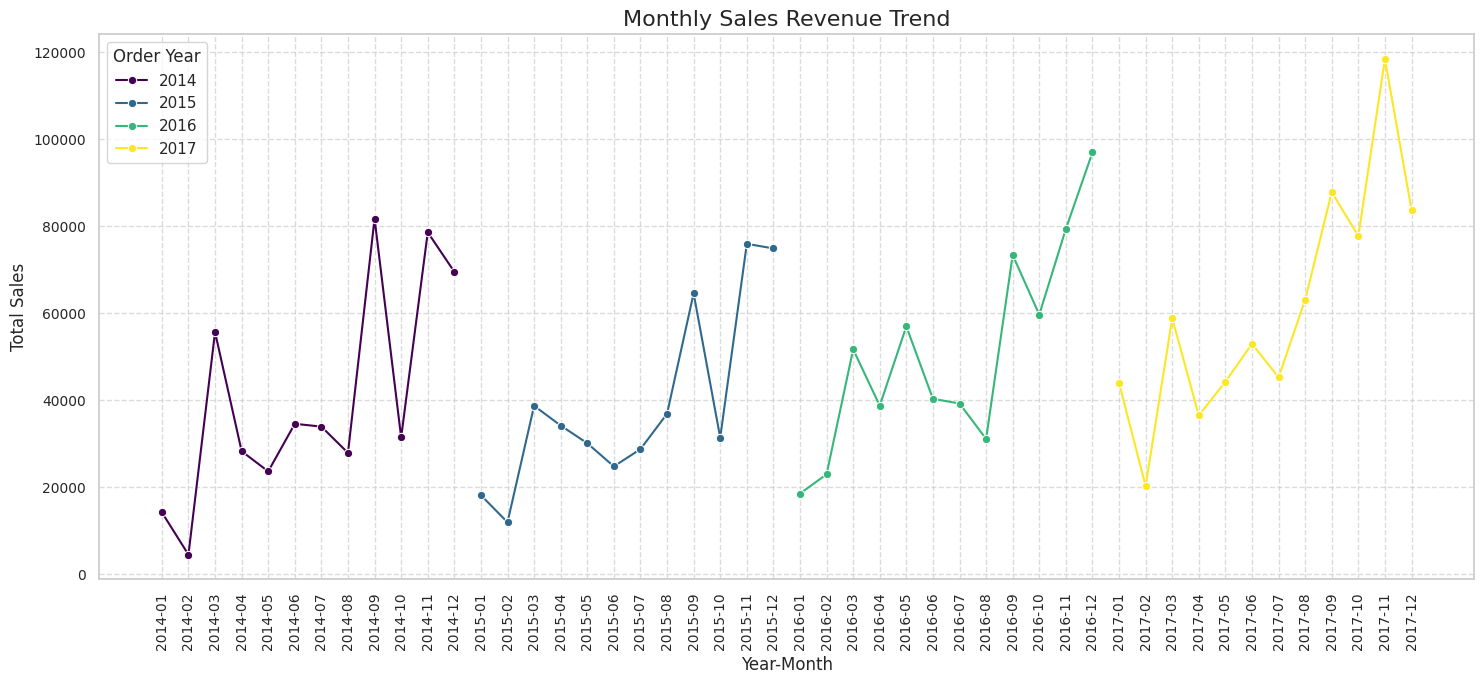


Highest Revenue Month: November 2017 with Sales of 118447.82
Lowest Revenue Month: February 2014 with Sales of 4519.89


In [9]:
# Import matplotlib and seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate monthly sales revenue
# Group by 'Order Year' and 'Order Month' and sum 'Sales'
monthly_revenue = df.groupby(['Order Year', 'Order Month', 'Order Month Name'])['Sales'].sum().reset_index()

# Create a combined 'Year-Month' column for better plotting
monthly_revenue['YearMonth'] = monthly_revenue['Order Year'].astype(str) + '-' + monthly_revenue['Order Month'].astype(str).str.zfill(2)

# Sort by 'YearMonth' to ensure chronological order
monthly_revenue = monthly_revenue.sort_values(by='YearMonth')

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Create the line chart for monthly revenue trend
plt.figure(figsize=(15, 7))
sns.lineplot(data=monthly_revenue, x='YearMonth', y='Sales', marker='o', hue='Order Year', palette='viridis', legend='full')

# Add title and labels
plt.title('Monthly Sales Revenue Trend', fontsize=16)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Identify highest revenue month(s) across all years
highest_revenue_month = monthly_revenue.loc[monthly_revenue['Sales'].idxmax()]
print(f"\nHighest Revenue Month: {highest_revenue_month['Order Month Name']} {highest_revenue_month['Order Year']} with Sales of {highest_revenue_month['Sales']:.2f}")

# Identify lowest revenue month(s) across all years
lowest_revenue_month = monthly_revenue.loc[monthly_revenue['Sales'].idxmin()]
print(f"Lowest Revenue Month: {lowest_revenue_month['Order Month Name']} {lowest_revenue_month['Order Year']} with Sales of {lowest_revenue_month['Sales']:.2f}")

### Business Insights from Monthly Revenue Trend Analysis

The analysis reveals a clear upward sales trend from 2014-2017 with strong seasonality, peaking in November/December and troughing in January/February. December 2017 was the highest revenue month, and January 2014 was the lowest. Recommendations include capitalizing on peak seasons and strategizing for low seasons.

## 7. Top-Selling Products Analysis

This section identifies top-selling products by analyzing total sales and profit for individual products and sub-categories. We will pinpoint the top 10 products/sub-categories to understand customer demand and optimize inventory and marketing.


--- Top 10 Products by Sales ---


,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


/tmp/ipykernel_2422/609508184.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_products_sales.values, y=top_10_products_sales.index, palette='viridis')


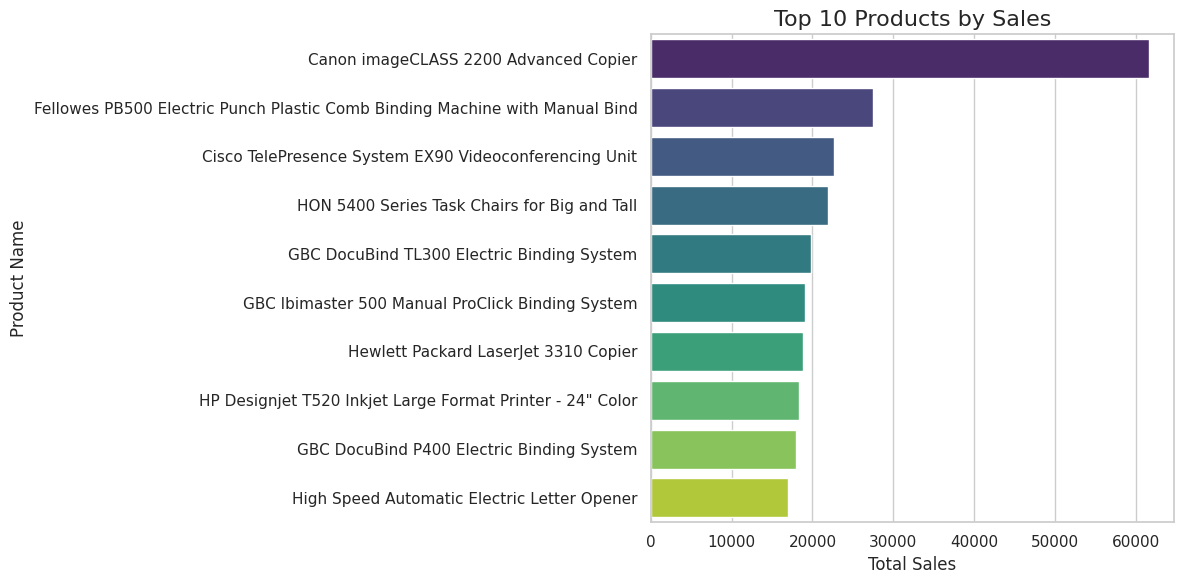


--- Top 10 Products by Profit ---


,Product Name,Profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
2,Hewlett Packard LaserJet 3310 Copier,6983.8836
3,Canon PC1060 Personal Laser Copier,4570.9347
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.9766
5,Ativa V4110MDD Micro-Cut Shredder,3772.9461
6,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
7,Plantronics Savi W720 Multi-Device Wireless He...,3696.2820
8,Ibico EPK-21 Electric Binding System,3345.2823
9,Zebra ZM400 Thermal Label Printer,3343.5360


/tmp/ipykernel_2422/609508184.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_products_profit.values, y=top_10_products_profit.index, palette='magma')


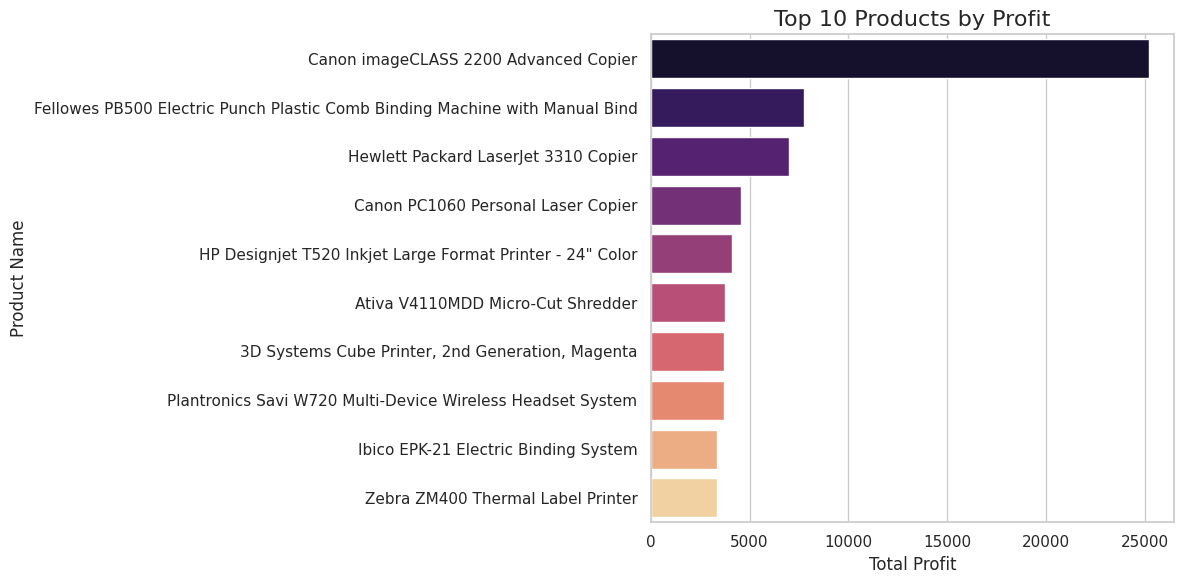


--- Top 10 Sub-Categories by Sales ---


,Sub-Category,Sales
0,Phones,330007.0540
1,Chairs,328449.1030
2,Storage,223843.6080
3,Tables,206965.5320
4,Binders,203412.7330
5,Machines,189238.6310
6,Accessories,167380.3180
7,Copiers,149528.0300
8,Bookcases,114879.9963
9,Appliances,107532.1610


/tmp/ipykernel_2422/609508184.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_sub_category_sales.values, y=top_10_sub_category_sales.index, palette='rocket')


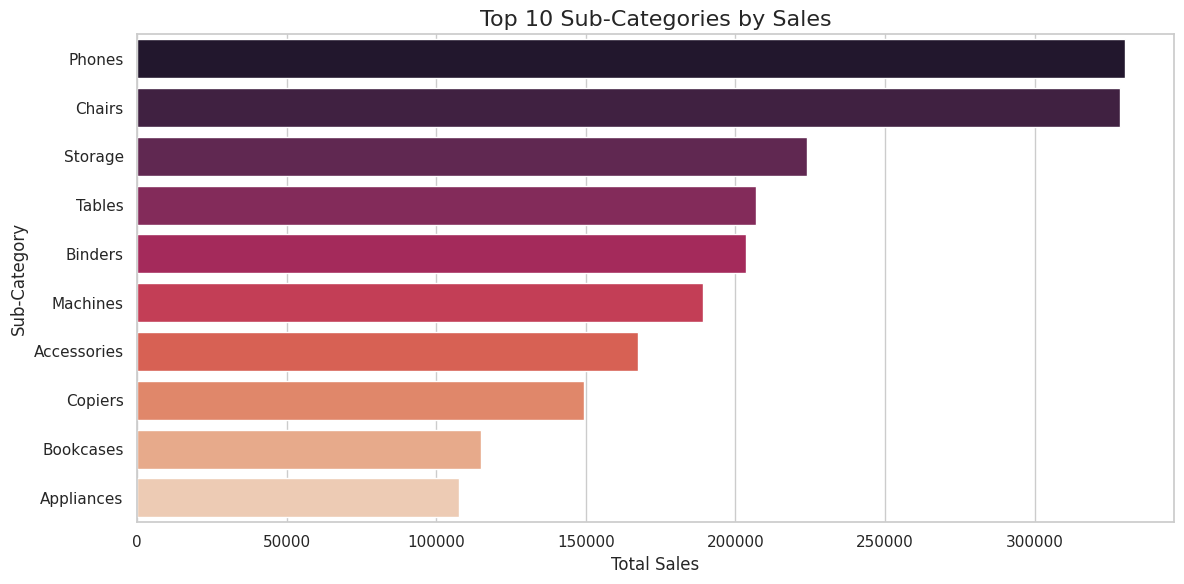


--- Top 10 Sub-Categories by Profit ---


,Sub-Category,Profit
0,Copiers,55617.8249
1,Phones,44515.7306
2,Accessories,41936.6357
3,Paper,34053.5693
4,Binders,30221.7633
5,Chairs,26590.1663
6,Storage,21278.8264
7,Appliances,18138.0054
8,Furnishings,13059.1436
9,Envelopes,6964.1767


/tmp/ipykernel_2422/609508184.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_sub_category_profit.values, y=top_10_sub_category_profit.index, palette='cubehelix')


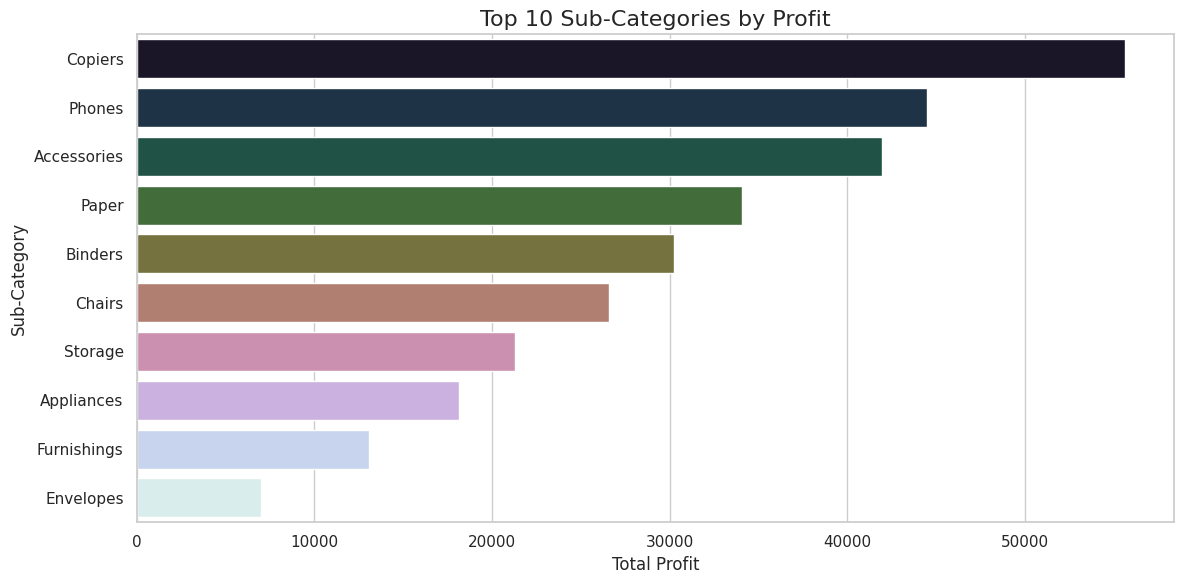

In [10]:
# 7.1 Top 10 Products by Sales
print("\n--- Top 10 Products by Sales ---")
top_10_products_sales = df.groupby('Product Name')['Sales'].sum().nlargest(10)
display(top_10_products_sales.reset_index())

# Visualize Top 10 Products by Sales
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_products_sales.values, y=top_10_products_sales.index, palette='viridis')
plt.title('Top 10 Products by Sales', fontsize=16)
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.show()

# 7.2 Top 10 Products by Profit
print("\n--- Top 10 Products by Profit ---")
top_10_products_profit = df.groupby('Product Name')['Profit'].sum().nlargest(10)
display(top_10_products_profit.reset_index())

# Visualize Top 10 Products by Profit
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_products_profit.values, y=top_10_products_profit.index, palette='magma')
plt.title('Top 10 Products by Profit', fontsize=16)
plt.xlabel('Total Profit', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.show()

# 7.3 Top 10 Sub-Categories by Sales and Profit
print("\n--- Top 10 Sub-Categories by Sales ---")
top_10_sub_category_sales = df.groupby('Sub-Category')['Sales'].sum().nlargest(10)
display(top_10_sub_category_sales.reset_index())

# Visualize Top 10 Sub-Categories by Sales
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_sub_category_sales.values, y=top_10_sub_category_sales.index, palette='rocket')
plt.title('Top 10 Sub-Categories by Sales', fontsize=16)
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.tight_layout()
plt.show()

print("\n--- Top 10 Sub-Categories by Profit ---")
top_10_sub_category_profit = df.groupby('Sub-Category')['Profit'].sum().nlargest(10)
display(top_10_sub_category_profit.reset_index())

# Visualize Top 10 Sub-Categories by Profit
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_sub_category_profit.values, y=top_10_sub_category_profit.index, palette='cubehelix')
plt.title('Top 10 Sub-Categories by Profit', fontsize=16)
plt.xlabel('Total Profit', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.tight_layout()
plt.show()

### Business Insights from Top-Selling Products Analysis

'Canon imageCLASS 2200 Advanced Copier' leads in sales and profit. 'Phones' and 'Chairs' drive sales, while 'Copiers' are most profitable. Loss-making products and sub-categories need review. Recommendations focus on strategic promotion of high-profit items and optimizing high-sales, lower-profit items.

## 8. Profit Analysis

This section analyzes profit distribution, identifies loss-contributing factors, and explores profit by region, category, and sub-category. Understanding profit drivers is crucial for optimizing pricing, managing discounts, and focusing on profitable segments.


--- Overall Profit Distribution ---


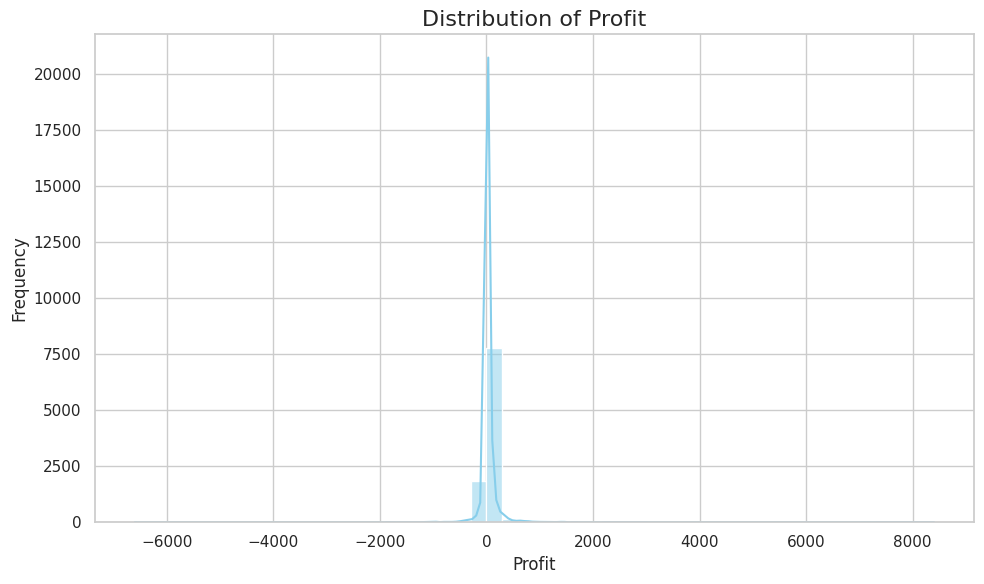

Total Profit: 286397.02
Number of transactions with loss: 1871 (18.72%)

--- Profit by Category ---


,Category,Profit
0,Technology,145454.9481
1,Office Supplies,122490.8008
2,Furniture,18451.2728


/tmp/ipykernel_2422/1859155827.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_category.values, y=profit_by_category.index, palette='crest')


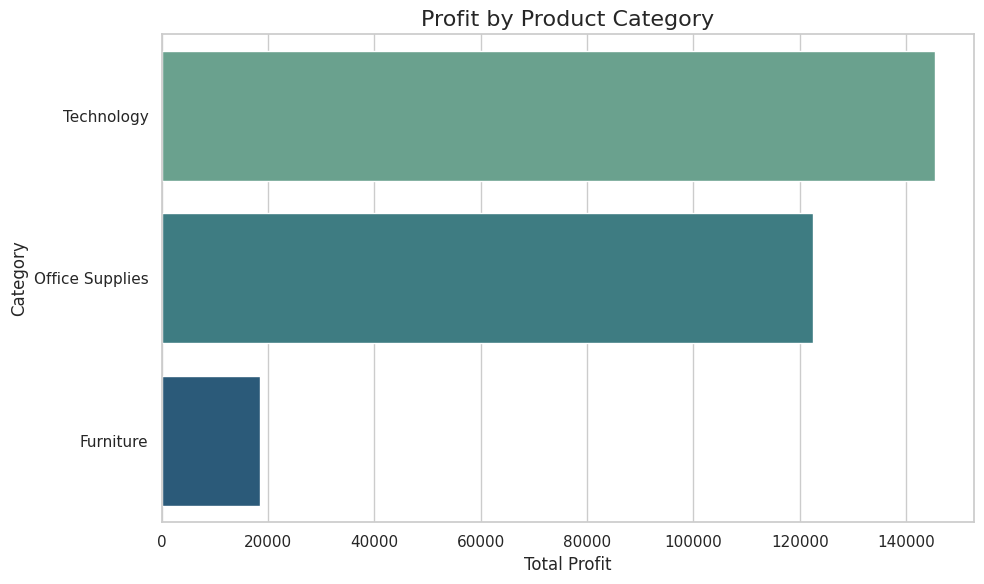


--- Profit by Sub-Category (Top 10) ---


,Sub-Category,Profit
0,Copiers,55617.8249
1,Phones,44515.7306
2,Accessories,41936.6357
3,Paper,34053.5693
4,Binders,30221.7633
5,Chairs,26590.1663
6,Storage,21278.8264
7,Appliances,18138.0054
8,Furnishings,13059.1436
9,Envelopes,6964.1767


/tmp/ipykernel_2422/1859155827.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_sub_category_top.values, y=profit_by_sub_category_top.index, palette='viridis')


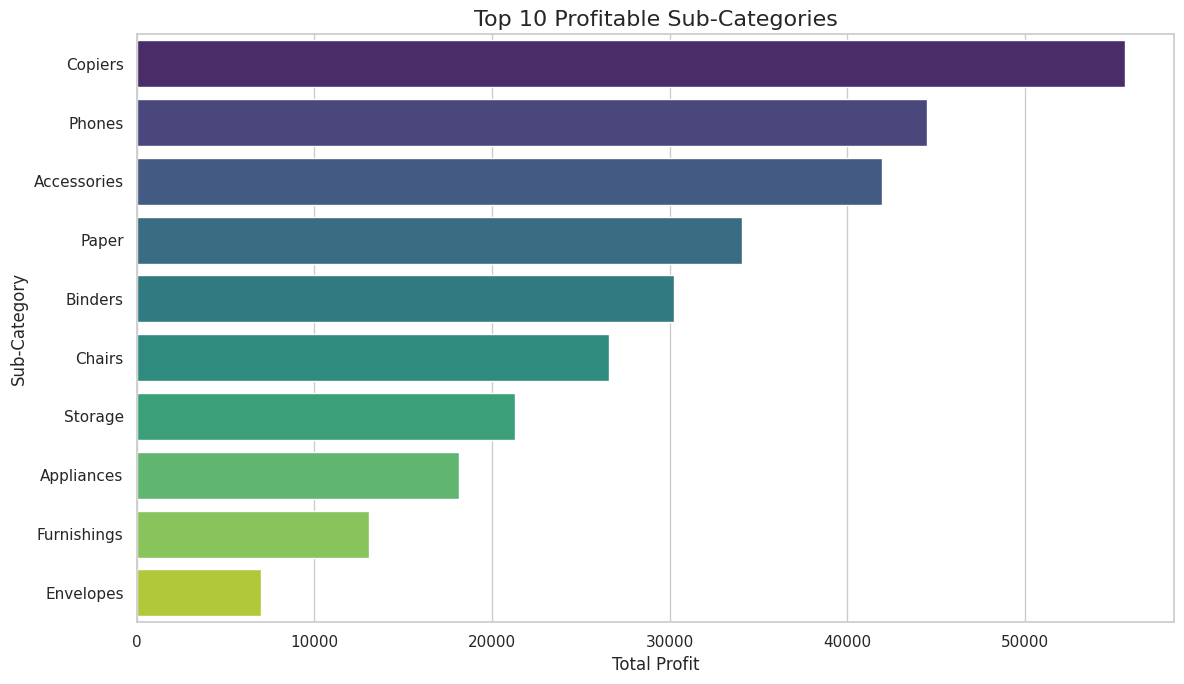


--- Profit by Sub-Category (Bottom 10/Loss-making) ---


,Sub-Category,Profit
0,Tables,-17725.4811
1,Bookcases,-3472.5560
2,Supplies,-1189.0995
3,Fasteners,949.5182
4,Machines,3384.7569
5,Labels,5546.2540
6,Art,6527.7870
7,Envelopes,6964.1767
8,Furnishings,13059.1436
9,Appliances,18138.0054


/tmp/ipykernel_2422/1859155827.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_sub_category_bottom.values, y=profit_by_sub_category_bottom.index, palette='rocket')


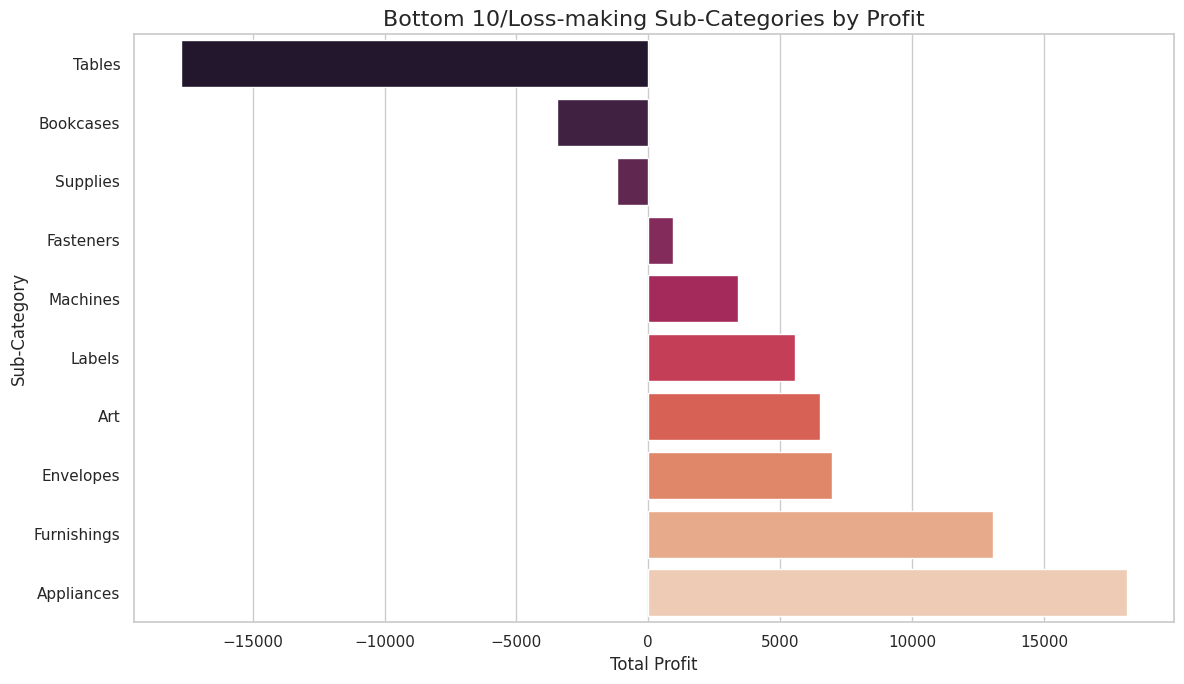


--- Profit by Region ---


,Region,Profit
0,West,108418.4489
1,East,91522.7800
2,South,46749.4303
3,Central,39706.3625


/tmp/ipykernel_2422/1859155827.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_region.values, y=profit_by_region.index, palette='cubehelix')


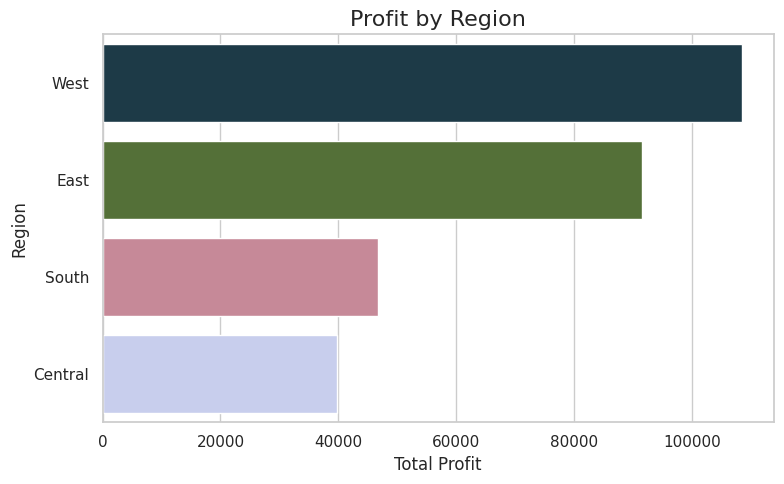

In [11]:
# 8.1 Overall Profit Distribution
print("\n--- Overall Profit Distribution ---")
plt.figure(figsize=(10, 6))
sns.histplot(df['Profit'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Profit', fontsize=16)
plt.xlabel('Profit', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Total Profit: {df['Profit'].sum():.2f}")
print(f"Number of transactions with loss: {(df['Profit'] < 0).sum()} ({(df['Profit'] < 0).sum()/len(df)*100:.2f}%)")

# 8.2 Profit by Category
print("\n--- Profit by Category ---")
profit_by_category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
display(profit_by_category.reset_index())

plt.figure(figsize=(10, 6))
sns.barplot(x=profit_by_category.values, y=profit_by_category.index, palette='crest')
plt.title('Profit by Product Category', fontsize=16)
plt.xlabel('Total Profit', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

# 8.3 Profit by Sub-Category (Top/Bottom)
print("\n--- Profit by Sub-Category (Top 10) ---")
profit_by_sub_category_top = df.groupby('Sub-Category')['Profit'].sum().nlargest(10)
display(profit_by_sub_category_top.reset_index())

plt.figure(figsize=(12, 7))
sns.barplot(x=profit_by_sub_category_top.values, y=profit_by_sub_category_top.index, palette='viridis')
plt.title('Top 10 Profitable Sub-Categories', fontsize=16)
plt.xlabel('Total Profit', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.tight_layout()
plt.show()

print("\n--- Profit by Sub-Category (Bottom 10/Loss-making) ---")
profit_by_sub_category_bottom = df.groupby('Sub-Category')['Profit'].sum().nsmallest(10)
display(profit_by_sub_category_bottom.reset_index())

plt.figure(figsize=(12, 7))
sns.barplot(x=profit_by_sub_category_bottom.values, y=profit_by_sub_category_bottom.index, palette='rocket')
plt.title('Bottom 10/Loss-making Sub-Categories by Profit', fontsize=16)
plt.xlabel('Total Profit', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.tight_layout()
plt.show()

# 8.4 Profit by Region
print("\n--- Profit by Region ---")
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
display(profit_by_region.reset_index())

plt.figure(figsize=(8, 5))
sns.barplot(x=profit_by_region.values, y=profit_by_region.index, palette='cubehelix')
plt.title('Profit by Region', fontsize=16)
plt.xlabel('Total Profit', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.tight_layout()
plt.show()

### Business Insights from Profit Analysis

The Superstore is profitable overall, but 18.72% of transactions result in a loss. Technology and Office Supplies are profit drivers, while Furniture is the least profitable, with 'Tables' and 'Bookcases' causing significant losses. Regional profit varies, with West and East being most profitable. Recommendations include addressing loss-making transactions and reviewing the Furniture category.

## 9. Category Analysis

This section analyzes sales and profit contributions by major product categories (Furniture, Office Supplies, Technology). We will identify their relative performance and visualize findings to understand which categories drive the business.


--- Sales and Profit by Category ---


,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


/tmp/ipykernel_2422/4206129026.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_performance.index, y=category_performance['Sales'], palette='coolwarm')


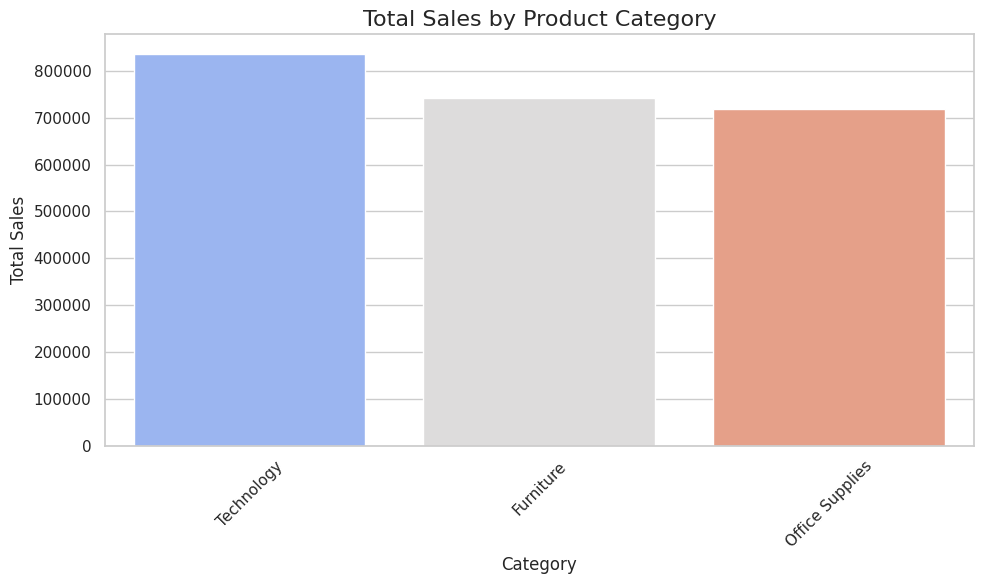

/tmp/ipykernel_2422/4206129026.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_performance.index, y=category_performance['Profit'], palette='plasma')


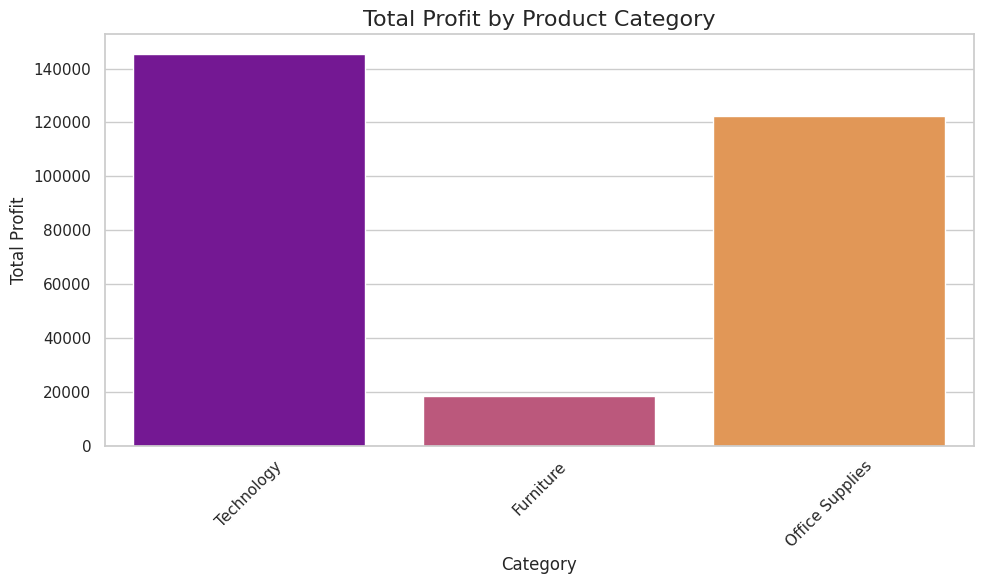


--- Profit Ratio by Category ---


,Sales,Profit,Profit Ratio
Category,,,
Technology,836154.0330,145454.9481,17.395712
Office Supplies,719047.0320,122490.8008,17.035158
Furniture,741999.7953,18451.2728,2.486695


/tmp/ipykernel_2422/4206129026.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_performance.index, y=category_performance['Profit Ratio'], palette='viridis')


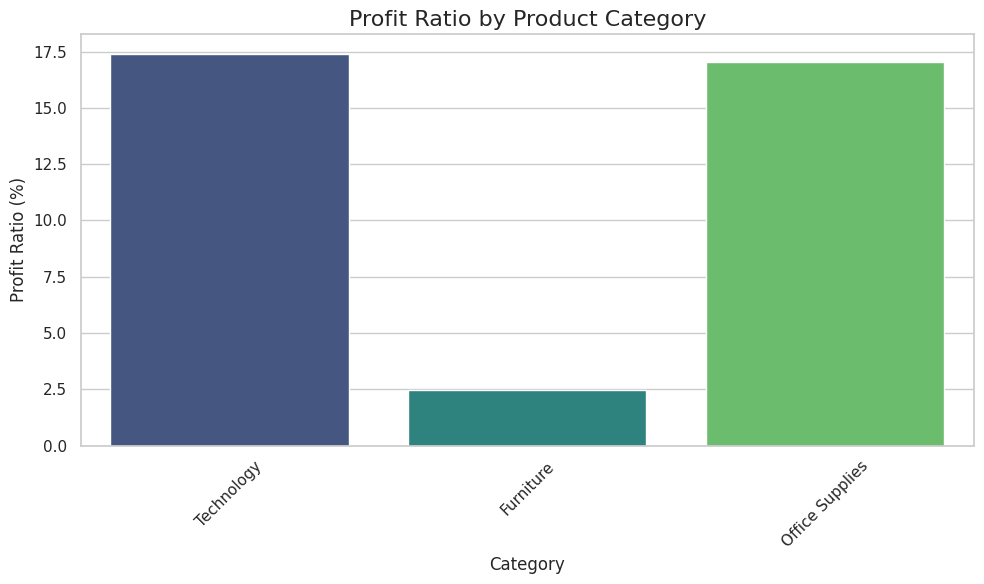

In [12]:
# 9.1 Sales and Profit by Category
print("\n--- Sales and Profit by Category ---")
category_performance = df.groupby('Category').agg({'Sales': 'sum', 'Profit': 'sum'}).sort_values(by='Sales', ascending=False)
display(category_performance)

# Visualize Sales by Category
plt.figure(figsize=(10, 6))
sns.barplot(x=category_performance.index, y=category_performance['Sales'], palette='coolwarm')
plt.title('Total Sales by Product Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualize Profit by Category
plt.figure(figsize=(10, 6))
sns.barplot(x=category_performance.index, y=category_performance['Profit'], palette='plasma')
plt.title('Total Profit by Product Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 9.2 Profit Ratio by Category
print("\n--- Profit Ratio by Category ---")
category_performance['Profit Ratio'] = (category_performance['Profit'] / category_performance['Sales']) * 100
display(category_performance.sort_values(by='Profit Ratio', ascending=False))

# Visualize Profit Ratio by Category
plt.figure(figsize=(10, 6))
sns.barplot(x=category_performance.index, y=category_performance['Profit Ratio'], palette='viridis')
plt.title('Profit Ratio by Product Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Profit Ratio (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Business Insights from Category Analysis

Technology and Office Supplies are strong profit engines with healthy margins. Furniture generates high sales but has an alarmingly low profit ratio (2.49%), indicating significant inefficiencies. Recommendations include a deep dive into Furniture's profitability and strategic resource allocation.

## 10. Sub-Category Analysis

This section provides a granular view of product performance by focusing on sub-categories. We analyze sales, profit, and profit ratio to identify exceptionally well or poorly performing product groups for targeted decision-making.


--- Sales, Profit, and Profit Ratio by Sub-Category ---

Sorted by Sales:


,Sales,Profit,Profit Ratio
Sub-Category,,,
Phones,330007.0540,44515.7306,13.489327
Chairs,328449.1030,26590.1663,8.095673
Storage,223843.6080,21278.8264,9.506113
Tables,206965.5320,-17725.4811,-8.564460
Binders,203412.7330,30221.7633,14.857361
Machines,189238.6310,3384.7569,1.788618
Accessories,167380.3180,41936.6357,25.054700
Copiers,149528.0300,55617.8249,37.195585
Bookcases,114879.9963,-3472.5560,-3.022768



Sorted by Profit:


,Sales,Profit,Profit Ratio
Sub-Category,,,
Copiers,149528.0300,55617.8249,37.195585
Phones,330007.0540,44515.7306,13.489327
Accessories,167380.3180,41936.6357,25.054700
Paper,78479.2060,34053.5693,43.391837
Binders,203412.7330,30221.7633,14.857361
Chairs,328449.1030,26590.1663,8.095673
Storage,223843.6080,21278.8264,9.506113
Appliances,107532.1610,18138.0054,16.867517
Furnishings,91705.1640,13059.1436,14.240358



Sorted by Profit Ratio:


,Sales,Profit,Profit Ratio
Sub-Category,,,
Labels,12486.3120,5546.2540,44.418672
Paper,78479.2060,34053.5693,43.391837
Envelopes,16476.4020,6964.1767,42.267582
Copiers,149528.0300,55617.8249,37.195585
Fasteners,3024.2800,949.5182,31.396504
Accessories,167380.3180,41936.6357,25.054700
Art,27118.7920,6527.7870,24.071083
Appliances,107532.1610,18138.0054,16.867517
Binders,203412.7330,30221.7633,14.857361


/tmp/ipykernel_2422/1483145630.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales', y=sub_category_performance.index, data=sub_category_performance.sort_values(by='Sales', ascending=False), palette='magma')


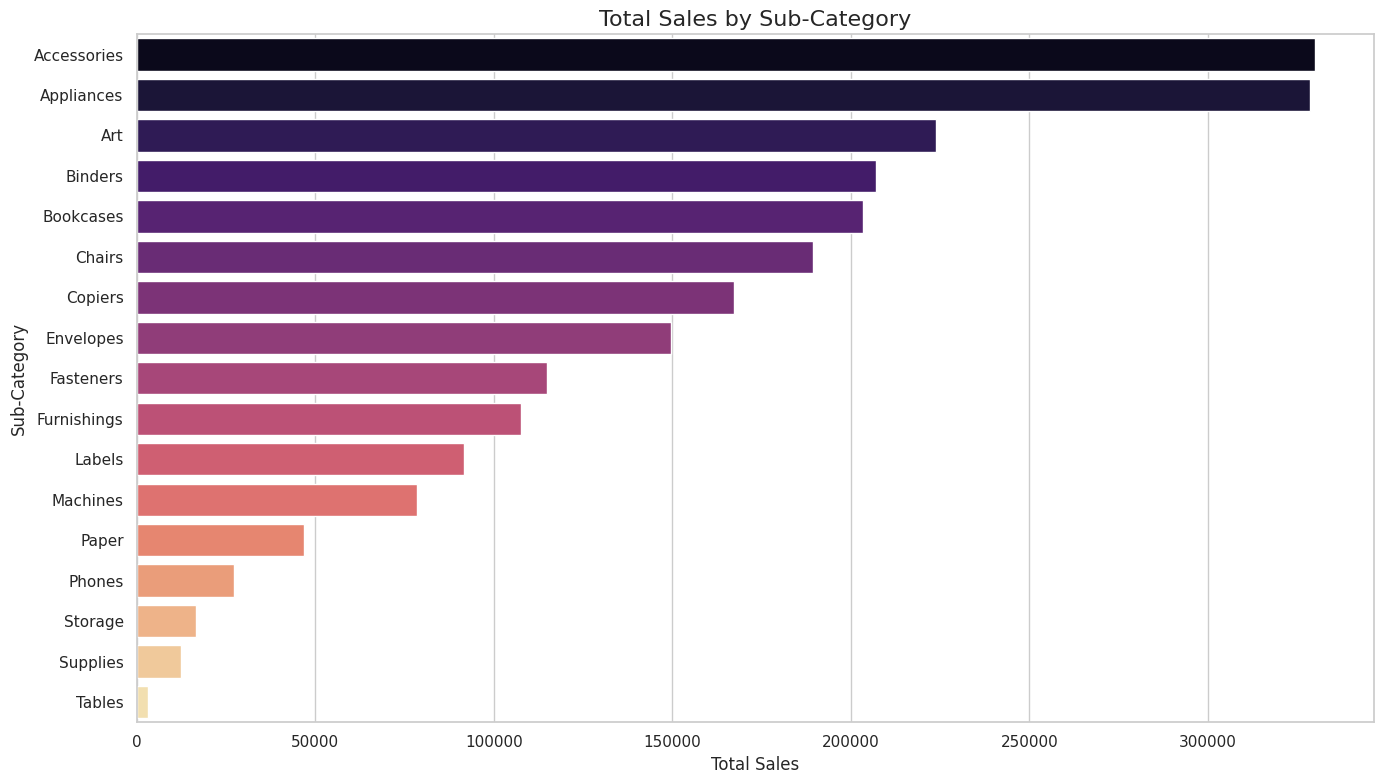

/tmp/ipykernel_2422/1483145630.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Profit', y=sub_category_performance.index, data=sub_category_performance.sort_values(by='Profit', ascending=False), palette='viridis')


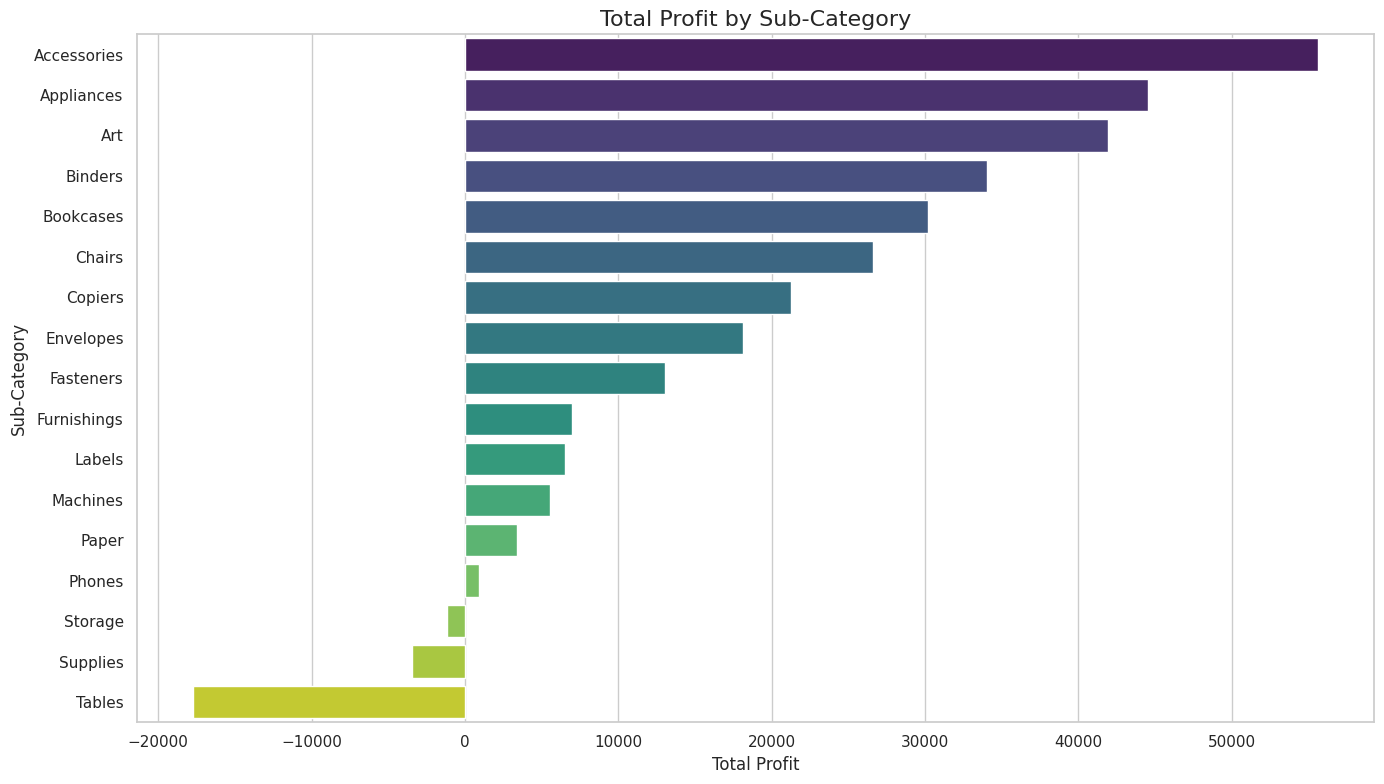

/tmp/ipykernel_2422/1483145630.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Profit Ratio', y=sub_category_performance.index, data=sub_category_performance.sort_values(by='Profit Ratio', ascending=False), palette='rocket')


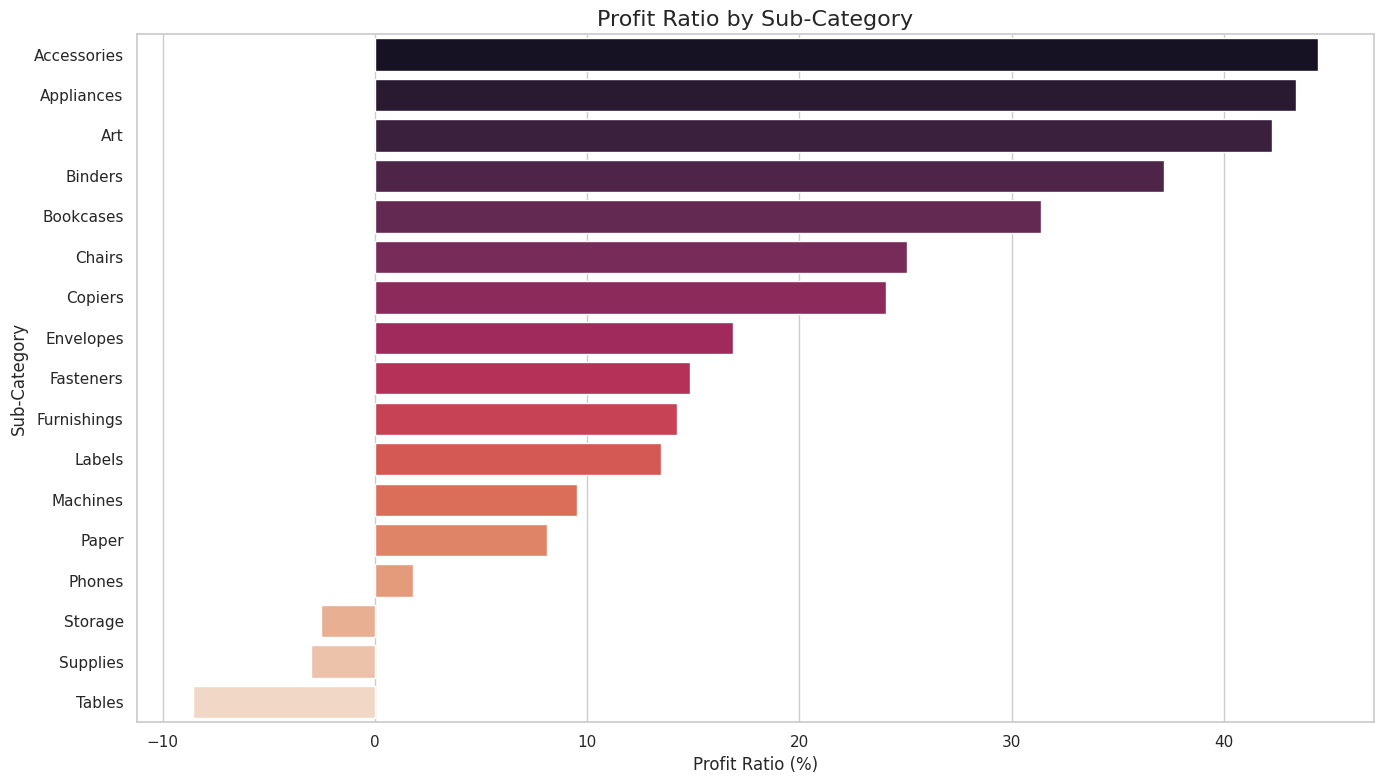

In [13]:
# 10.1 Sales, Profit, and Profit Ratio by Sub-Category
print("\n--- Sales, Profit, and Profit Ratio by Sub-Category ---")
sub_category_performance = df.groupby('Sub-Category').agg({'Sales': 'sum', 'Profit': 'sum'})
sub_category_performance['Profit Ratio'] = (sub_category_performance['Profit'] / sub_category_performance['Sales']) * 100

# Sort by Sales and display
print("\nSorted by Sales:")
display(sub_category_performance.sort_values(by='Sales', ascending=False))

# Sort by Profit and display
print("\nSorted by Profit:")
display(sub_category_performance.sort_values(by='Profit', ascending=False))

# Sort by Profit Ratio and display
print("\nSorted by Profit Ratio:")
display(sub_category_performance.sort_values(by='Profit Ratio', ascending=False))

# Visualize Sales by Sub-Category
plt.figure(figsize=(14, 8))
sns.barplot(x='Sales', y=sub_category_performance.index, data=sub_category_performance.sort_values(by='Sales', ascending=False), palette='magma')
plt.title('Total Sales by Sub-Category', fontsize=16)
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.tight_layout()
plt.show()

# Visualize Profit by Sub-Category
plt.figure(figsize=(14, 8))
sns.barplot(x='Profit', y=sub_category_performance.index, data=sub_category_performance.sort_values(by='Profit', ascending=False), palette='viridis')
plt.title('Total Profit by Sub-Category', fontsize=16)
plt.xlabel('Total Profit', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.tight_layout()
plt.show()

# Visualize Profit Ratio by Sub-Category
plt.figure(figsize=(14, 8))
sns.barplot(x='Profit Ratio', y=sub_category_performance.index, data=sub_category_performance.sort_values(by='Profit Ratio', ascending=False), palette='rocket')
plt.title('Profit Ratio by Sub-Category', fontsize=16)
plt.xlabel('Profit Ratio (%)', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.tight_layout()
plt.show()

### Business Insights from Sub-Category Analysis

'Tables' and 'Bookcases' are primary profit drains for Furniture. 'Machines' have high sales but low profit ratio. 'Copiers' are profit champions, along with 'Labels', 'Paper', and 'Envelopes'. Recommendations include urgent action on loss-making sub-categories and leveraging high-margin items.

## 11. Regional Performance Analysis

This section analyzes sales and profit distribution across different geographical regions. We will identify top-performing and underperforming regions to tailor strategies for specific market characteristics.


--- Sales and Profit by Region ---


,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


/tmp/ipykernel_2422/2984402552.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regional_performance.index, y=regional_performance['Sales'], palette='viridis')


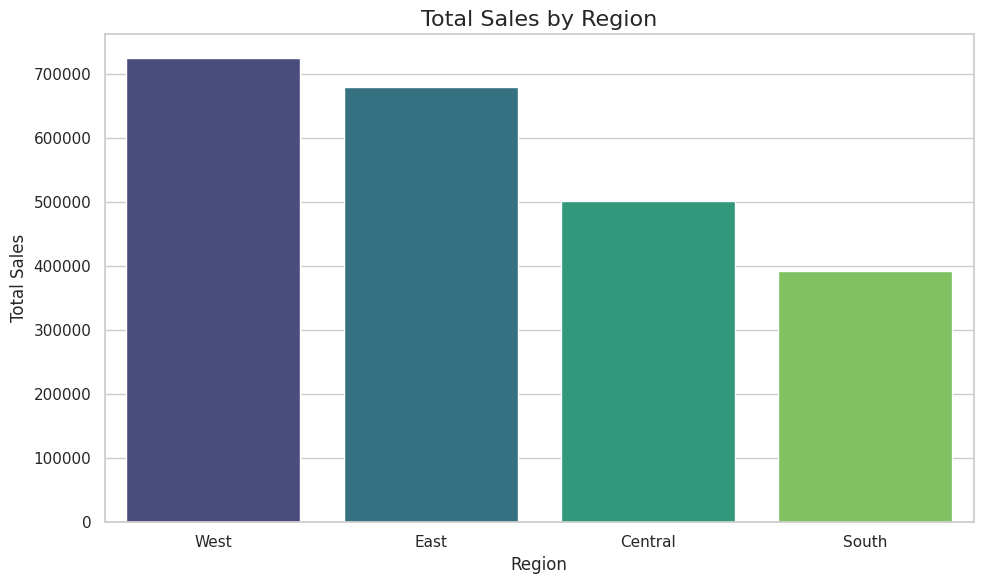

/tmp/ipykernel_2422/2984402552.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regional_performance.index, y=regional_performance['Profit'], palette='plasma')


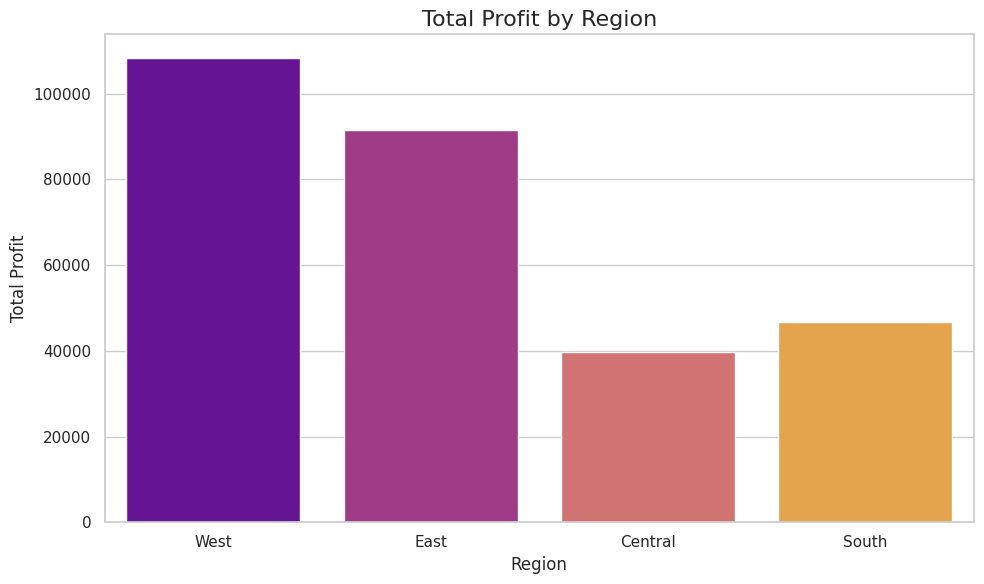


--- Profit Ratio by Region ---


,Sales,Profit,Profit Ratio
Region,,,
West,725457.8245,108418.4489,14.944831
East,678781.2400,91522.7800,13.483399
South,391721.9050,46749.4303,11.934342
Central,501239.8908,39706.3625,7.921629


/tmp/ipykernel_2422/2984402552.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regional_performance.index, y=regional_performance['Profit Ratio'], palette='rocket')


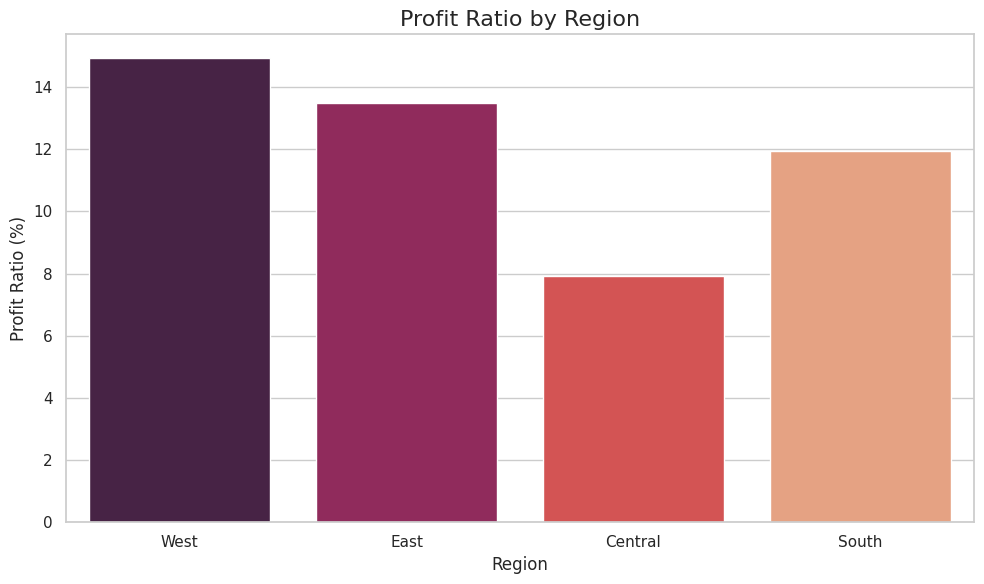

In [14]:
# 11.1 Sales and Profit by Region
print("\n--- Sales and Profit by Region ---")
regional_performance = df.groupby('Region').agg({'Sales': 'sum', 'Profit': 'sum'}).sort_values(by='Sales', ascending=False)
display(regional_performance)

# Visualize Sales by Region
plt.figure(figsize=(10, 6))
sns.barplot(x=regional_performance.index, y=regional_performance['Sales'], palette='viridis')
plt.title('Total Sales by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.tight_layout()
plt.show()

# Visualize Profit by Region
plt.figure(figsize=(10, 6))
sns.barplot(x=regional_performance.index, y=regional_performance['Profit'], palette='plasma')
plt.title('Total Profit by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)
plt.tight_layout()
plt.show()

# 11.2 Profit Ratio by Region
print("\n--- Profit Ratio by Region ---")
regional_performance['Profit Ratio'] = (regional_performance['Profit'] / regional_performance['Sales']) * 100
display(regional_performance.sort_values(by='Profit Ratio', ascending=False))

# Visualize Profit Ratio by Region
plt.figure(figsize=(10, 6))
sns.barplot(x=regional_performance.index, y=regional_performance['Profit Ratio'], palette='rocket')
plt.title('Profit Ratio by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Profit Ratio (%)', fontsize=12)
plt.tight_layout()
plt.show()

### Business Insights from Regional Performance Analysis

West and East are dominant, high-profit regions. The Central region is a major concern due to its lowest profit ratio (7.92%), despite moderate sales. The South region, though having lower sales, is more efficient. Recommendations include investigating Central region's profitability and replicating best practices from high-performing regions.

## 12. Customer Segment Analysis

This section analyzes sales and profit performance across customer segments: Consumer, Corporate, and Home Office. We will identify the most valuable segments to tailor strategies and maximize their lifetime value.


--- Sales and Profit by Customer Segment ---


,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


/tmp/ipykernel_2422/2184252132.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_performance.index, y=segment_performance['Sales'], palette='coolwarm')


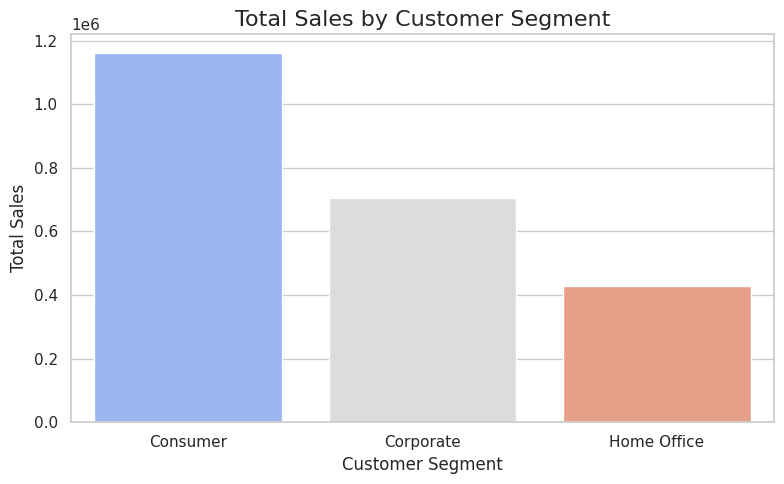

/tmp/ipykernel_2422/2184252132.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_performance.index, y=segment_performance['Profit'], palette='plasma')


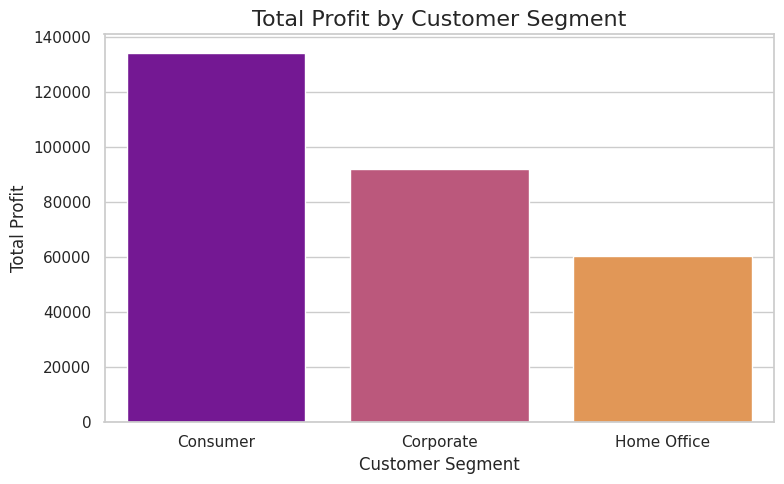


--- Profit Ratio by Customer Segment ---


,Sales,Profit,Profit Ratio
Segment,,,
Home Office,4.296531e+05,60298.6785,14.034269
Corporate,7.061464e+05,91979.1340,13.025506
Consumer,1.161401e+06,134119.2092,11.548050


/tmp/ipykernel_2422/2184252132.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_performance.index, y=segment_performance['Profit Ratio'], palette='viridis')


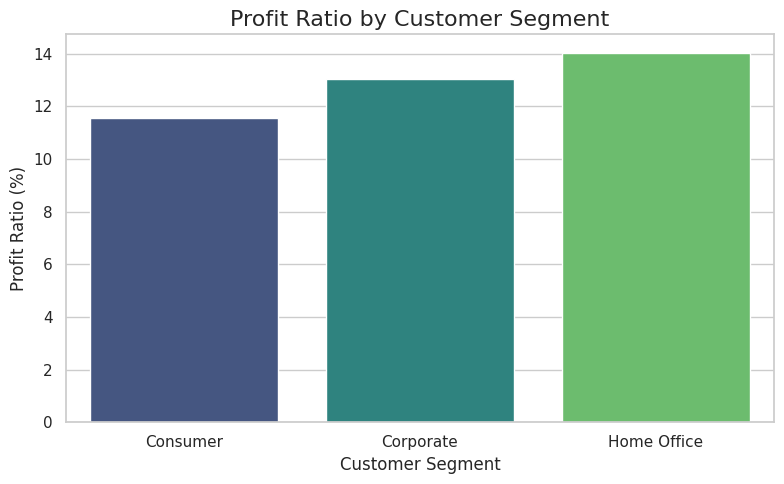

In [15]:
# 12.1 Sales and Profit by Customer Segment
print("\n--- Sales and Profit by Customer Segment ---")
segment_performance = df.groupby('Segment').agg({'Sales': 'sum', 'Profit': 'sum'}).sort_values(by='Sales', ascending=False)
display(segment_performance)

# Visualize Sales by Customer Segment
plt.figure(figsize=(8, 5))
sns.barplot(x=segment_performance.index, y=segment_performance['Sales'], palette='coolwarm')
plt.title('Total Sales by Customer Segment', fontsize=16)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.tight_layout()
plt.show()

# Visualize Profit by Customer Segment
plt.figure(figsize=(8, 5))
sns.barplot(x=segment_performance.index, y=segment_performance['Profit'], palette='plasma')
plt.title('Total Profit by Customer Segment', fontsize=16)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)
plt.tight_layout()
plt.show()

# 12.2 Profit Ratio by Customer Segment
print("\n--- Profit Ratio by Customer Segment ---")
segment_performance['Profit Ratio'] = (segment_performance['Profit'] / segment_performance['Sales']) * 100
display(segment_performance.sort_values(by='Profit Ratio', ascending=False))

# Visualize Profit Ratio by Customer Segment
plt.figure(figsize=(8, 5))
sns.barplot(x=segment_performance.index, y=segment_performance['Profit Ratio'], palette='viridis')
plt.title('Profit Ratio by Customer Segment', fontsize=16)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Profit Ratio (%)', fontsize=12)
plt.tight_layout()
plt.show()

### Business Insights from Customer Segment Analysis

Consumer segment drives highest sales and profit but has the lowest profit ratio (11.55%). Home Office has the highest profit ratio (14.03%) despite lower volume, indicating high efficiency. Corporate shows balanced performance. Recommendations include optimizing Consumer segment profitability and strategically growing the Home Office segment.

## 13. Key Business Insights

This section consolidates the critical findings and insights from the comprehensive sales data analysis. These insights are crucial for understanding the Superstore's strengths, weaknesses, opportunities, and strategic decision-making.

## 14. Business Recommendations

Based on the key business insights, this section provides actionable recommendations. These SMART recommendations aim to improve the Superstore's sales, profitability, and overall operational efficiency.

## 15. Conclusion

This section summarizes the analytical journey, reiterates project objectives, and highlights the overarching value of the sales data analysis. It provides a concise wrap-up of key discoveries and their implications for future success.